In [ ]:
# 메모리 캐시 제거
torch.cuda.empty_cache()

### pip install 묶음

In [ ]:
!pip install -U transformers

In [ ]:
!pip install compressed-tensors

# 라이브러리 임포트

In [ ]:
import torch
import json

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
torch.manual_seed(123)  # 시드설정

# Qwen3-1.7B-양자화 모델 불러오기

In [ ]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForCausalLM

# Qwen3 1.7B 모델 불러오기
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-1.7B", padding_side="left")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-1.7B")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwe

##### 예제1

In [ ]:
#------------------------- 예제 --------------------------------
# 간단한 메시지 작성
messages = [
    {"role": "user", "content": "Who are you?"},
]

# 메세지에 대한간단한 input, output 형성
# input
inputs = tokenizer.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(device)


# output
outputs = model.generate(**inputs, max_new_tokens=40)

# 출력
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))
#---------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

<think>
Okay, the user asked, "Who are you?" I need to respond in a friendly and helpful way. Let me start by introducing myself as an AI assistant. I should mention that I


In [ ]:
# 대화 루프 시작
while True:
    # 1. 사용자로부터 질문 입력받기
    user_input = input("You: ")

    # 'exit'를 입력하면 루프 종료
    if user_input.lower() == 'exit':
        print("챗봇을 종료합니다.")
        break

    # 2. 대화 형식에 맞게 메시지 구성
    messages = [
        {"role": "user", "content": user_input},
    ]

    # 3. 입력 텍스트를 토큰화하고 텐서로 변환
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(device)

    # 4. 모델을 통해 답변 생성
    # pad_token_id는 생성 중 경고 메시지를 없애기 위해 추가
    outputs = model.generate(
        **inputs,
        max_new_tokens=128, # 답변 최대 길이 설정
        pad_token_id=tokenizer.eos_token_id
    )

    # 5. 생성된 답변에서 입력 부분을 제외하고 디코딩
    response_ids = outputs[0][inputs["input_ids"].shape[-1]:]
    response_text = tokenizer.decode(response_ids, skip_special_tokens=True)

    # 6. 모델의 답변 출력
    print(f"Qwen: {response_text}")


You: Hello, do you speak Korean?
Qwen: <think>
Okay, the user asked if I can speak Korean. I need to confirm my ability to do so. Let me check my current capabilities. I'm a large language model, so I should have support for multiple languages, including Korean. But I should make sure to mention that my proficiency might be limited compared to native speakers. I should also offer to help with any Korean-related tasks the user might have. Let me structure the response clearly and politely.
</think>

Yes, I can speak Korean! While I may not be a native speaker, I can understand and respond in Korean to a certain extent. If you have any questions or
You: 안녕, 너는 누구니?
Qwen: <think>
Okay, the user asked, "안녕, 너는 누구니?" which means "Hello, who are you?" in Korean. I need to respond in a friendly and helpful way.

First, I should acknowledge their greeting. Maybe say something like "안녕하세요!" to reply. Then introduce myself clearly. I should mention my name and that I'm here to help. 

I should k

### 데이터 셋 형성 (Q&A 리스트 형식)

In [ ]:
qna_list = []
max_data_set = 100

# 파일 이름을 .jsonl로 변경하고, 인코딩을 utf-8로 지정
with open("/content/drive/MyDrive/main/Qwen 학습/training_data_10000.jsonl", "r", encoding="utf-8") as file:
    for i, line in enumerate(file):

        # 처음부터 max_data_set까지
        if i == max_data_set:
            break

        # 1. JSONL 파일의 각 줄을 파싱하여 파이썬 딕셔너리로 변환
        data = json.loads(line)

        # 2. 파싱된 데이터에서 질문(question)과 답변(answers) 추출
        question = data['question']
        # 답변 형식에 맞게 'answers' 리스트를 단일 문자열로 변환
        answers_formatted = " // ".join([f"{ans['term']}: {ans['definition']}" for ans in data['answers']])

        # 10개만 형식을 유지하는지 확인
        if i <= 10:
            print(f'{question}\n{answers_formatted}')
            print('-'*80)


        # 3. messages 리스트 구성
        messages = [
            {"role": "system", "content": "You are an assistant that explains terms about ship building."},
            {"role": "user", "content": question},
            {"role": "assistant", "content": answers_formatted}
        ]

        # print(i, messages)


        # 질문과 전체 응답 프롬프트
        q = tokenizer.apply_chat_template(messages[:2], tokenize=False, add_generation_prompt=True)
        input_str = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

        # 글자를 숫자로 인코딩
        q_ids = tokenizer.encode(q, add_special_tokens=False)
        input_ids = tokenizer.encode(input_str, add_special_tokens=False)

        # 딕셔너리 형태로 qna 리스트에 추가
        qna_list.append({'q': q, 'input': input_str, 'q_ids': q_ids, 'input_ids': input_ids})



# 가장 긴 토큰의 길이 확인
if qna_list: # 리스트가 비어있지 않은 경우에만 max_length 계산
    max_length = max(len(i['input_ids']) for i in qna_list)
    print(f"가장 긴 토큰의 길이: {max_length}")
else:
    print("처리된 데이터가 없습니다.")


새로 건조된 선박에는 최신 LENGTH OF WATER LINE와(과) middlength beam 시스템이 장착되어 있습니다.
LENGTH OF WATER LINE: 수선장 // middlength beam: 중앙부폭: 계획만재흘수선에서의 중앙부 단면의 폭
--------------------------------------------------------------------------------
선박 설계 시 진주채취선의 기준을 반드시 준수해야 합니다.
진주채취선: Pearl Boat: 진주조개를 채취할 목적으로 만든 배
--------------------------------------------------------------------------------
매뉴얼에 CATHODIC PROTECTION와(과) 수용시설 관련 내용이 어디에 있는지 찾아봐 주세요.
CATHODIC PROTECTION: 음극 방식(陰極防蝕) // 수용시설: Reception facilities: 선박으로부터 배출되는 선박평형수 또는 침전물을 수용하는 시설을 말하며, 선박평형수 또는 침전물의 저장, 육상양육 또는 수용시설에서 직접 처리 후 해양으로 배출할 수 있는 시설임.
--------------------------------------------------------------------------------
이번 프로젝트에서는 WIRE GUY 개념을 이해하는 것이 중요합니다.
WIRE GUY: 와이어가이: 와이어로프로 만든 가이
--------------------------------------------------------------------------------
OIL BRAKE의 정확한 의미를 아는 사람 있나요?
OIL BRAKE: 유압브레이크: 유압으로 작동시키는 제동장치
--------------------------------------------------------------------------------
우리는 INTERCONNECTION PI

##### 파인튜닝 전의 답변 확인

In [ ]:
# 질문만 들어있는 리스트 생성
questions = [ qna['q'] for qna in qna_list ]

# 파인튜닝 하기 전 질문하기
questions.append("Draft의 뜻에 대해 설명해줘?")
questions.append("매뉴얼에 OECD 해운위원회 관련 내용이 어디에 있는지 찾아봐 주세요.")
questions.append("새로 건조된 선박에는 최신 코밍 시스템이 장착되어 있습니다.")

# 토큰 ID 리스트로 변경
input_ids = tokenizer(
    questions,
    padding=True,
    return_tensors="pt",
)["input_ids"].to(device)

# 평가용으로 모델 전환
model.eval()

# output 응답 생성
with torch.no_grad():
    output = model.generate(
        input_ids,
        max_new_tokens=256,  # 최대 256토큰까지 답변 생성
        do_sample=True,
        temperature=0.7,
        top_k=50
    )

# output 결과를 리스트로 형변환
output_list = output.tolist()

# 각 한줄 한줄마다 output 출력
for i, output in enumerate(output_list):
    print(f"Q{i}: {tokenizer.decode(output, skip_special_tokens=True)}")

Q0: system
You are an assistant that explains terms about ship building.
user
새로 건조된 선박에는 최신 LENGTH OF WATER LINE와(과) middlength beam 시스템이 장착되어 있습니다.
assistant
<think>
Okay, the user is asking about the "length of the water line" and "middle of the water line" in shipbuilding. Let me explain these terms in simple terms.

First, I need to clarify what these terms mean. "Length of the water line" refers to the length of the ship from the forward end to the aft end, which is measured from the bow (front) to the stern (back) of the ship. It's a key measurement for determining the ship's size and stability. The "middle of the water line" is the midship section, which is the midpoint of the ship's length. 

But wait, maybe I should check if the user is referring to the "length of the waterline" as the length of the ship's hull at the waterline, which is the length of the ship when it's floating in water. The "middle of the water line" might be the midpoint of that length. 

Wait, maybe I sho

# 학습

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# 151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
EOT = 151643

# 나의 데이터셋을 정의하는 클래스 객체 생성
class MyDataset(Dataset):
    # 초기화 함수
    def __init__(self, qna_list, max_length):
        self.input_ids = []
        self.target_ids = []

        # 질문 리스트의 요소별로 정의
        for qa in qna_list:
            token_ids = qa['input_ids']     # Q&A의 전체 문자열 토큰 ID 리스트
            input_chunk = token_ids         # 이를 input_chunk
            target_chunk = token_ids[1:]    # A가 되는 target_chunck 문자열 토큰 ID 리스트

            input_chunk += [EOT]* (max_length - len(input_chunk))       # input_chunk에 [EOT]토큰 수를 최대길이에서 부족한 만큼 추가
            target_chunk +=  [EOT]* (max_length - len(target_chunk))    # target_chunk도 마찮가지로 [EOT]토큰 수를 부족한 만큼 추가

            len_ignore = len(qa['q_ids']) - 1                   # target은 한 글자가 짧기 때문
            target_chunk[:len_ignore] = [-100] * len_ignore     # 질문에 대해서는 학습하지 않도록

            self.input_ids.append(torch.tensor(input_chunk))    # input_ids에 input_chunck 추가
            self.target_ids.append(torch.tensor(target_chunk))  # target_ids에 target_chunck 추가


    # 총 데이터의 갯수를 알려주는 역할
    def __len__(self):
        return len(self.input_ids)

    # 특정 데이터를 꺼내오는 역할
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


In [ ]:
from torch.utils.data import random_split

# 데이터셋 정의
dataset = MyDataset(qna_list, max_length=max_length)

# 1. 전체 데이터셋의 크기를 계산합니다.
total_size = len(dataset)

# 2. 분리할 크기를 결정합니다 (예: 80% 학습, 20% 테스트).
train_size = int(total_size * 0.8)
test_size = total_size - train_size

# 3. random_split 함수를 사용하여 데이터셋을 분리합니다.
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# 4. 분리된 데이터셋의 크기를 확인합니다.
print(f"전체 데이터셋 크기: {total_size}")
print(f"학습 데이터셋 크기: {len(train_dataset)}")
print(f"테스트 데이터셋 크기: {len(test_dataset)}")

전체 데이터셋 크기: 100
학습 데이터셋 크기: 80
테스트 데이터셋 크기: 20


In [ ]:
# 데이터셋 불러오기   collate_fn=data_collator
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, drop_last=False)

##### 한개씩 끊어서 확인

In [ ]:
i = iter(train_loader)      # 데이터를 한개씩 출력하는 요소
x, y = next(i)              # 하나를 뽑아 x와 y에 배정 (x는 Q, y는 A)

# 첫번째 요소에 대해 분석 -> EOT 토큰 제거
y_temp = y[0].tolist()
y_temp = [x for x in y_temp if x != -100]

# 첫번재 x에 대하여 디코딩하고, 첫번째 답변 디코딩
print("Q&A 전문")
print(tokenizer.decode(x[0].tolist()))
print('='*80)
print("Q를 보고 유추한 A의 응답")
print(tokenizer.decode(y_temp))

Q&A 전문
<|im_start|>system
You are an assistant that explains terms about ship building.<|im_end|>
<|im_start|>user
선박 설계 시 진주채취선의 기준을 반드시 준수해야 합니다.<|im_end|>
<|im_start|>assistant
<think>

</think>

진주채취선: Pearl Boat: 진주조개를 채취할 목적으로 만든 배<|im_end|>
<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext

### 데이터 학습

In [ ]:
model.gradient_checkpointing_enable()

In [ ]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)    # 최적화 파라미터 설정

# 지금까지 본 토큰의 수, 전체 학습 진행 횟수
tokens_seen, global_step = 0, -1

losses = []     # 학습 시 loss를 담을 리스트

# 10번 반복하여 학습
for epoch in range(10):
    model.train()   # 모델을 학습 모드로 변경
    epoch_loss = 0  # 현재 회차의 loss

    # train_loader에 있는 input_batch와 target_batch로 학습 진행
    for input_batch, target_batch in train_loader:

        optimizer.zero_grad()   # 최적화 로스 초기화
        input_batch, target_batch = input_batch.to(device), target_batch.to(device) # GPU 할당

        with autocast(): # 이 블록 안에서 모델을 실행해야 합니다.
            logits = model(input_batch).logits

            # 크로스엔트로피 로스 구하기
            loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
            epoch_loss += loss.item()   # 로스추가
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients

        # 해당 학습 기록하기
        tokens_seen += input_batch.numel()
        global_step += 1

        # 몇번째 학습 진행중, 토큰은 n개 확인함
        print(f"{global_step} Tokens seen: {tokens_seen}")

    # 전체 데이터에 대한 학습이 끝나고
    avg_loss = epoch_loss / len(train_loader)   # 평균 loss구하기
    losses.append(avg_loss)                     # 해당 평균 loss를 기록
    # n번째 학습, 평균 loss
    print(f"Epoch: {epoch}, Loss: {avg_loss}")

    # 해당 모델을 저장
    # torch.save(model.state_dict(), "model_" + str(epoch).zfill(3) + ".pth")


/tmp/ipython-input-917545738.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-917545738.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 이 블록 안에서 모델을 실행해야 합니다.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


0 Tokens seen: 1660
1 Tokens seen: 3320
2 Tokens seen: 4980
3 Tokens seen: 6640
4 Tokens seen: 8300
5 Tokens seen: 9960
6 Tokens seen: 11620
7 Tokens seen: 13280
8 Tokens seen: 14940
9 Tokens seen: 16600
10 Tokens seen: 18260
11 Tokens seen: 19920
12 Tokens seen: 21580
13 Tokens seen: 23240
14 Tokens seen: 24900
15 Tokens seen: 26560
16 Tokens seen: 28220
17 Tokens seen: 29880
18 Tokens seen: 31540
19 Tokens seen: 33200
20 Tokens seen: 34860
21 Tokens seen: 36520
22 Tokens seen: 38180
23 Tokens seen: 39840
24 Tokens seen: 41500
25 Tokens seen: 43160
26 Tokens seen: 44820
27 Tokens seen: 46480
28 Tokens seen: 48140
29 Tokens seen: 49800
30 Tokens seen: 51460
31 Tokens seen: 53120
32 Tokens seen: 54780
33 Tokens seen: 56440
34 Tokens seen: 58100
35 Tokens seen: 59760
36 Tokens seen: 61420
37 Tokens seen: 63080
38 Tokens seen: 64740
39 Tokens seen: 66400
Epoch: 0, Loss: 0.4056416442617774
40 Tokens seen: 68060
41 Tokens seen: 69720
42 Tokens seen: 71380
43 Tokens seen: 73040
44 Tokens see

In [ ]:
torch.cuda.empty_cache()    # GPU 캐시 초기화

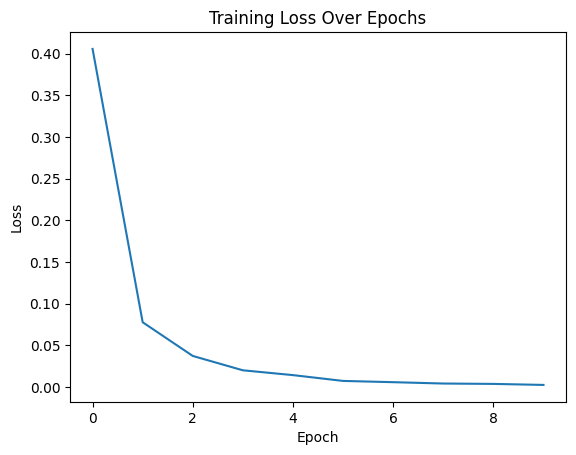

In [ ]:
# Loss 그래프
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show()

In [ ]:
# 파인튜닝 후에 어떻게 응답하는지 확인
# 모델 불러오기
model.load_state_dict(torch.load("best.pt", map_location=device, weights_only=True))
model.eval()

In [ ]:
# 파인튜닝 후에 어떻게 대답하는지 확인
import random

# random.sample()을 사용하여 셔플된 '새로운' 리스트를 생성합니다.
# 원본 qna_list는 변경되지 않습니다.
shuffled_qna_list = random.sample(qna_list, k=len(qna_list))

# 셔플된 새 리스트에서 q_ids를 추출합니다.
questions = [qna['q_ids'] for i, qna in enumerate(shuffled_qna_list) if i <= 10 ]

prompt_tensor = torch.tensor([q_ids]).to("cuda")
attention_mask_tensor = (prompt_tensor != tokenizer.pad_token_id).long()

for i, q_ids in enumerate(questions):

    model.eval()
    with torch.no_grad():
        output = model.generate(
            torch.tensor([q_ids]).to(device),
            max_new_tokens=500,
            attention_mask=attention_mask_tensor,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            temperature=1,
            top_k=5
        ) # temperature 랑 top_k 파라미터 조절

    output_list = output.tolist()
    print(f"Q{i}: {tokenizer.decode(output[0], skip_special_tokens=True)}")

Q0: system
You are an assistant that explains terms about ship building.
user
우리는 회전력와(과) 의무선와(과) 웰갑판 기술을 도입하여 효율성을 높였습니다.
assistant
<think>

</think>

회전력: Turning Force: 물체에 회전력을 발생시키기 위하여 물체에 회전력을 발생시키기 위하여 물체에 회전력을 발생시키는 힘 성분 // 의무선: Obliged Vessel: 해상충돌방지 법규에 따라 침로와 속력 등을 변경하여 피할 의무가 있는 선박 // 웰갑판: Well Deck: 선수루와 선미루가 분리되어있는 선박에서 선루가 없는 부분의 상갑판
Q1: system
You are an assistant that explains terms about ship building.
user
선박 설계 시 hydraulic power pack와(과) DIGITAL ANALOG CONVERTER의 기준을 반드시 준수해야 합니다.
assistant
<think>

</think>

hydraulic power pack: 유압(油壓)발생장치 // DIGITAL ANALOG CONVERTER: 디지털 아나로그 변환기
Q2: system
You are an assistant that explains terms about ship building.
user
이번 프로젝트에서는 공통 구조 규칙 개념을 이해하는 것이 중요합니다.
assistant
<think>

</think>

공통 구조 규칙: Common Structural Rules: 국제선급연합회(IACS)에서 IMO GBS 규정에 따라 개발한 선체 구조 규칙으로써 생명, 환경 및 재산의 안전성을 개선하고 선박의 설계 수명 동안 선체 구조의 내구성을 지속시키기 위하여 주요 선체 구조의 결함을 완화하는 최소한의 요구 사항을 설정함. 선박의 구조 강도 및 수밀 구조가 상세 요건을 만족하도록 함
Q3: system
You are an assistant t

RuntimeError: The size of tensor a (455) must match the size of tensor b (69) at non-singleton dimension 2

In [ ]:
# Shape 찾아서 비교
torch.tensor